In [ ]:
#IMPORTS

import re
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.signal import hilbert
from scipy.signal import find_peaks

In [16]:
#NAMING SETUP

base_dir = Path("metingen")

position_names = [f"0-{i}" for i in range(1, 5)] + [f"{i}-4" for i in range(1, 5)]

def numbered_names(prefix, count):
    return [prefix] + [f"{prefix} ({i})" for i in range(1, count)]

raw_source_names = numbered_names("usr_wf_C1_data", 3) #3 raw replicate files
fft_source_names = numbered_names("usr_wf_F1_data", 3) #3 fft replicate files

In [17]:
#LENGTHS

length_pattern = re.compile(r"(\d+(?:\.\d+)?)\s*cm")

def parse_length(folder_name):
    match = length_pattern.search(folder_name)
    if match:
        return float(match.group(1))
    print(f"Could not parse length from folder name: {folder_name}")
    return None

In [18]:
#FORCES

g = 9.81 #m/s
notch_to_ratio = {0: 0, 1: 4, 2: 6, 3: 8, 4: 10} #notch to lever ratio
gewicht_1 = 1.0468 #kg
gewicht_2 = 1.0436 #kg

def position_force(position):
    w2_notch, w1_notch = (int(n) for n in position.split("-"))
    return gewicht_1*g*notch_to_ratio[w1_notch]+gewicht_2*g*notch_to_ratio[w2_notch]

forces_arr = np.array([position_force(p) for p in position_names], dtype=float)

In [19]:
#FOLDER NAMES AND LENGTHS

cm_folders = sorted(f for f in base_dir.iterdir() if f.is_dir() and "23" not in f.name)

length_names_sorted = [f.name for f in cm_folders]
lengths_arr = np.array([parse_length(name) for name in length_names_sorted])

In [20]:
#GET SHAPE

def find_shape(source_names):
    for cm_folder in cm_folders:
        for position in position_names:
            position_folder = cm_folder / f"metingen {position}"
            for source_name in source_names:
                file_path = position_folder / f"{source_name}.csv"
                if file_path.exists():
                    return np.loadtxt(file_path, skiprows=12, delimiter=",").shape
    raise FileNotFoundError("No files found to determine shape")

raw_shape = find_shape(raw_source_names)
fft_shape = find_shape(fft_source_names)

In [21]:
#PREALLOCATE FINAL ARRAYS

n_lengths = len(cm_folders)
n_positions = len(position_names)
n_replicates = 3

raw_array = np.full((n_lengths, n_positions, n_replicates, *raw_shape), np.nan)
fft_array = np.full((n_lengths, n_positions, n_replicates, *fft_shape), np.nan)

In [22]:
#LOAD FILES INTO ARRAY SLOTS

for i, cm_folder in enumerate(cm_folders):
    print(f"Processing folder: {cm_folder.name}")
    for j, position in enumerate(position_names):
        position_folder = cm_folder / f"metingen {position}"
        if not position_folder.is_dir():
            print(f"  Missing folder: {position_folder}")
            continue

        for r, source_name in enumerate(raw_source_names, start=1):
            file_path = position_folder / f"{source_name}.csv"
            if file_path.exists():
                raw_array[i, j, r - 1] = np.loadtxt(file_path, skiprows=12, delimiter=",")
            else:
                print(f"     Missing file: {file_path}")

        for r, source_name in enumerate(fft_source_names, start=1):
            file_path = position_folder / f"{source_name}.csv"
            if file_path.exists():
                fft_array[i, j, r - 1] = np.loadtxt(file_path, skiprows=12, delimiter=",")
            else:
                print(f"     Missing file: {file_path}")

print("raw_array shape:", raw_array.shape)
print("fft_array shape:", fft_array.shape)

Processing folder: metingen 25.5 cm
Processing folder: metingen 27 cm
Processing folder: metingen 28.5 cm
Processing folder: metingen 30 cm
Processing folder: metingen 31.5 cm
raw_array shape: (5, 8, 3, 10000, 2)
fft_array shape: (5, 8, 3, 4096, 5)


In [23]:
#METADATA GRIDS

length_grid = np.broadcast_to(lengths_arr[:, None], (n_lengths, n_positions))
force_grid = np.broadcast_to(forces_arr[None, :], (n_lengths, n_positions))

In [24]:
#TAKING USEFUL DATA FROM FFT ARRAYS

fft_avg = np.nanmean(fft_array, axis=2)
frequency = fft_avg[:, :, :, 0]
magnitude = fft_avg[:, :, :, 3]

freq_idx = np.nanargmax(magnitude, axis=-1)
peak_freq = np.take_along_axis(frequency, freq_idx[..., None], axis=-1).squeeze(-1)

In [25]:
#TRIMMING WITH HILBERT

margin_samples = 200
time_col, voltage_col = 0, 1

n_lengths, n_positions, n_replicates, n_samples_raw, n_cols_raw = raw_array.shape
start_indices = np.zeros((n_lengths, n_positions, n_replicates), dtype=int)

for i in range(n_lengths):
    for j in range(n_positions):
        for r in range(n_replicates):
            voltage = raw_array[i, j, r, :, voltage_col]
            if np.all(np.isnan(voltage)):
                start_indices[i, j, r] = n_samples_raw  # nothing usable
                continue
            envelope = np.abs(hilbert(np.nan_to_num(voltage)))
            peak_idx = np.argmax(envelope)
            start_indices[i, j, r] = peak_idx + margin_samples

#every signal keeps the same number of points after its own start, so the result stays rectangular
trimmed_length = n_samples_raw - start_indices.max()
if trimmed_length <= 0:
    raise ValueError("margin_samples too large — no usable samples left after trimming")

raw_trimmed = np.full((n_lengths, n_positions, n_replicates, trimmed_length, n_cols_raw), np.nan)

for i in range(n_lengths):
    for j in range(n_positions):
        for r in range(n_replicates):
            start = start_indices[i, j, r]
            if start >= n_samples_raw:
                continue
            raw_trimmed[i, j, r] = raw_array[i, j, r, start:start + trimmed_length, :]

In [26]:
#DOING FFT ON TRIMMED DATA WITH SAME SETTINGS AS OSCILLOSCOPE

dt = np.nanmedian(np.diff(raw_array[0, 0, 0, :, time_col])) #sampling interval
fs = 1 / dt

window = np.hanning(trimmed_length)
window_gain = window.mean() #coherent gain correction, so windowing doesn't shrink the reported amplitude

voltage_trimmed = raw_trimmed[:, :, :, :, voltage_col] #shape (n_lengths, n_positions, n_replicates, trimmed_length)
windowed = voltage_trimmed * window #broadcasts the window over the last axis

spectrum = np.fft.rfft(windowed, axis=-1)
freqs = np.fft.rfftfreq(trimmed_length, d=dt)

magnitude_lin = np.abs(spectrum) / (trimmed_length * window_gain)
magnitude_lin[..., 1:] *= 2 #one-sided spectrum: double every bin except DC

magnitude_dBV = 20 * np.log10(magnitude_lin) #dBV = 20*log10(V / 1V reference)

#restrict to the oscilloscope's displayed span: center 400 Hz, span 1 kHz
center, span = 400, 1000
f_lo, f_hi = max(0, center - span / 2), center + span / 2
band = (freqs >= f_lo) & (freqs <= f_hi)

freqs_band = freqs[band]
magnitude_band = magnitude_dBV[:, :, :, band]

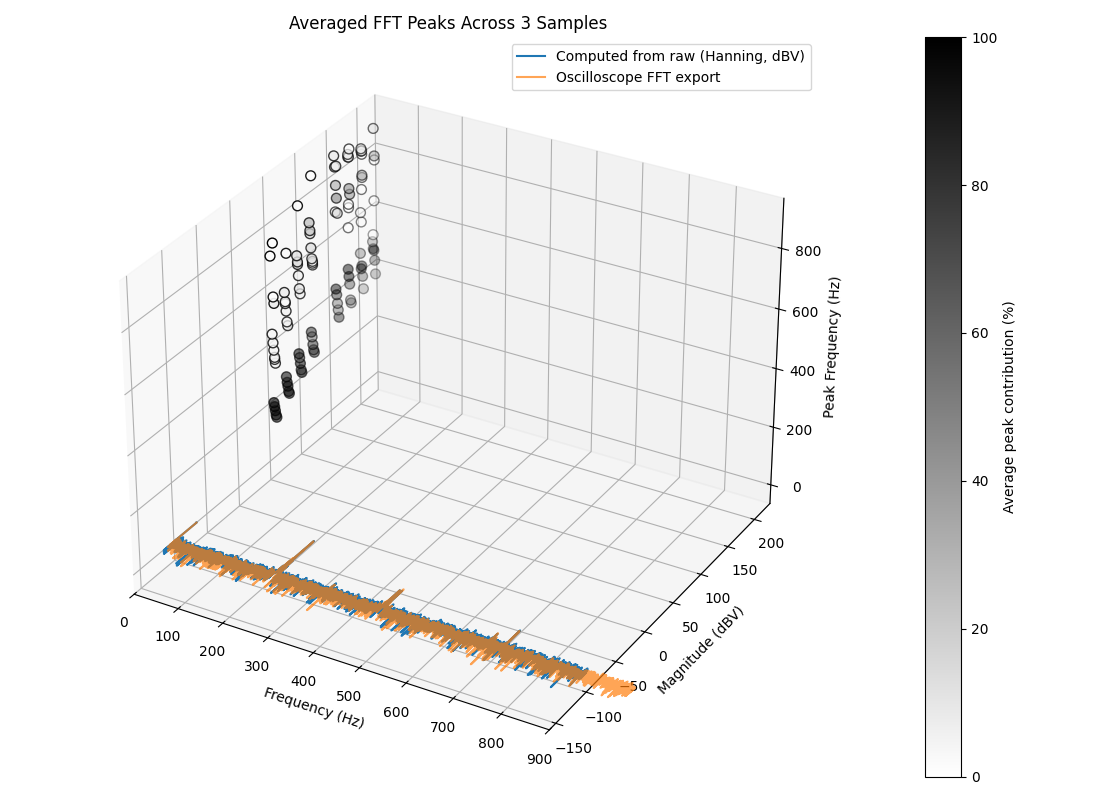

In [27]:
#SANTIY CHECK (CHECK IF GRAPHS ARE SIMILAR)

#keep in mind the oscilloscope fft used the entire timeline, while the computed fft used the trimmed timeline
#this means there should be some differences, but as long as the main peaks are in the same spots its good

i, j, r = 0, 0, 0 #pick one example cell to compare

osc_freq = fft_array[i, j, r, :, 0]
osc_mag = fft_array[i, j, r, :, 3]

plt.plot(freqs_band, magnitude_band[i, j, r], label="Computed from raw (Hanning, dBV)")
plt.plot(osc_freq, osc_mag, label="Oscilloscope FFT export", alpha=0.7)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dBV)")
plt.xlim(f_lo, f_hi)
plt.legend()
plt.show()

Magnitude band shape:
(5, 8, 3, 4310)
Lengths: 5
Forces: 8
Samples: 3
Frequencies: 4310

frequency range: 0.0 to 899.9582289055966 Hz
global minimum: -158.00128114177798 dBV
global maximum: -32.65772420218816 dBV

Frequency resolution: 0.20885547201336657 Hz
Peak matching tolerance: 6 Hz
Minimum valid peak frequency: 2 Hz

Found 103 averaged peaks

Averaged peaks:

Length = 25.5, Force = 41.076432, Frequency = 231.55 Hz, Magnitude = 0.0085357 V, Contribution = 91.37%, Samples = 3/3
Length = 25.5, Force = 41.076432, Frequency = 465.19 Hz, Magnitude = 0.00033134 V, Contribution = 3.55%, Samples = 3/3
Length = 25.5, Force = 41.076432, Frequency = 726.29 Hz, Magnitude = 0.00021325 V, Contribution = 1.53%, Samples = 2/3
Length = 25.5, Force = 61.614647999999995, Frequency = 284.60 Hz, Magnitude = 0.015115 V, Contribution = 85.11%, Samples = 3/3
Length = 25.5, Force = 61.614647999999995, Frequency = 571.53 Hz, Magnitude = 0.0013206 V, Contribution = 7.45%, Samples = 3/3
Length = 25.5, Force 

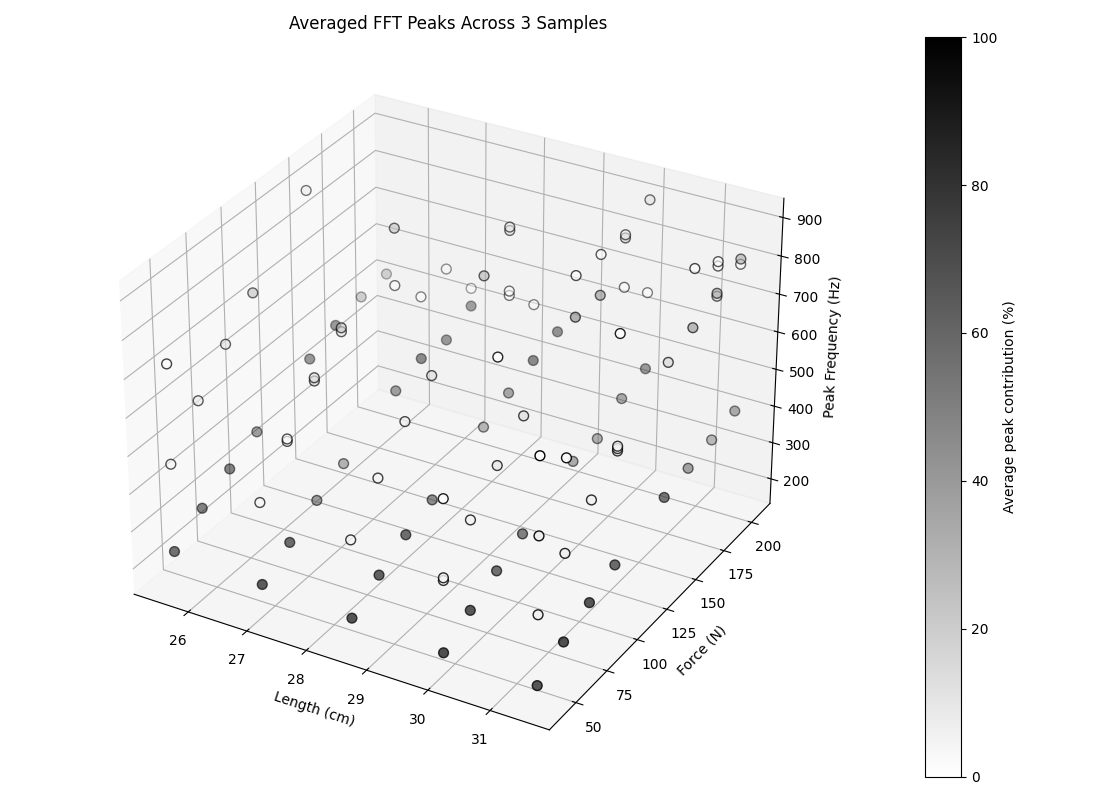

In [28]:
%matplotlib widget

#CHECK GRID DIMENSIONS

if length_grid.shape != magnitude_band.shape[:2]:
    raise ValueError(f"length_grid has shape {length_grid.shape}, but magnitude_band has first two dimensions {magnitude_band.shape[:2]}\n")

if force_grid.shape != magnitude_band.shape[:2]:
    raise ValueError(f"force_grid has shape {force_grid.shape}, but magnitude_band has first two dimensions {magnitude_band.shape[:2]}\n")

#CHECK DATA DIMENSIONS

n_lengths = magnitude_band.shape[0]
n_forces = magnitude_band.shape[1]
n_samples = magnitude_band.shape[2]
n_frequencies = magnitude_band.shape[3]

print("Magnitude band shape:")
print(magnitude_band.shape)

print(f"Lengths: {n_lengths}")
print(f"Forces: {n_forces}")
print(f"Samples: {n_samples}")
print(f"Frequencies: {n_frequencies}\n")

if n_samples != 3:
    raise ValueError(f"Expected 3 samples, but found {n_samples}.\n")

#DATA DIAGNOSTICS

print(f"frequency range: {freqs_band[0]} to {freqs_band[-1]} Hz")
print(f"global minimum: {np.nanmin(magnitude_band)} dBV")
print(f"global maximum: {np.nanmax(magnitude_band)} dBV\n")

#PEAK-DETECTION SETTINGS

#minimum frequency that can be considered a valid peak
MIN_PEAK_FREQUENCY_HZ = 2 #Hz

#minimum height above the average level of the individual FFT
BACKGROUND_MARGIN_DB = 20 #Db

#minimum number of FFT bins between detected peaks
MIN_DISTANCE_BINS = 20

#determine frequency resolution from the actual FFT
frequency_resolution = freqs_band[1]-freqs_band[0]

#peaks in different samples within this frequency range will be considered the same physical peak
PEAK_MATCH_TOLERANCE_HZ = 6 #Hz

#weight peak contribution according to how many samples contain the peak
SAMPLE_CONSISTENCY_WEIGHT = True

print(f"Frequency resolution: {frequency_resolution} Hz")
print(f"Peak matching tolerance: {PEAK_MATCH_TOLERANCE_HZ} Hz")
print(f"Minimum valid peak frequency: {MIN_PEAK_FREQUENCY_HZ} Hz\n")

#FIND PEAKS IN ONE INDIVIDUAL FFT

#find significant peaks in one individual FFT
#peak contribution is calculated using linear amplitude, therefore detected peaks sum to 100%
def find_peaks_in_fft(spectrum_here, freqs_band):
    valid = np.isfinite(spectrum_here)
    if not np.any(valid):
        return (np.array([]), np.array([]), np.array([]))

    spectrum_db = spectrum_here.copy()
    if not np.all(valid):
        spectrum_db[~valid] = np.nanmedian(spectrum_db)

    spectrum_linear = 10**(spectrum_db/20)
    mean_linear = np.mean(spectrum_linear)
    if mean_linear <= 0:
        return (np.array([]), np.array([]), np.array([]))
    mean_db = 20*np.log10(mean_linear)

    #find local peaks
    candidate_indices, _ = find_peaks(spectrum_db, distance=MIN_DISTANCE_BINS)
    if len(candidate_indices) == 0:
        return (np.array([]), np.array([]), np.array([]))

    #remove 0 hz disturbance
    candidate_indices = candidate_indices[freqs_band[candidate_indices] >= MIN_PEAK_FREQUENCY_HZ]
    if len(candidate_indices) == 0:
        return (np.array([]), np.array([]), np.array([]))

    #candidate peak magnitudes
    peak_db = spectrum_db[candidate_indices]
    peak_above_mean_db = peak_db-mean_db
    significant = (peak_above_mean_db >= BACKGROUND_MARGIN_DB)
    peak_indices = candidate_indices[significant]

    if len(peak_indices) == 0:
        return (np.array([]), np.array([]), np.array([]))

    #get peak frequencies
    peak_freqs = freqs_band[peak_indices]

    #get peak magnitudes
    peak_db_values = spectrum_db[peak_indices]
    peak_linear = 10**(peak_db_values/20)

    #calculate peak contribution
    total_peak_linear = np.sum(peak_linear)
    if total_peak_linear > 0:
        peak_percent = peak_linear/total_peak_linear*100
    else:
        peak_percent = np.zeros(len(peak_linear))

    return (peak_freqs, peak_linear, peak_percent)

#MATCH PEAKS BETWEEN THE 3 SAMPLES

#match peaks from the three samples by frequency
#peaks within tolerance_hz are treated as the same physical peak
#frequency, magnitude and contribution are averaged
#contribution is reduced when the peak is found in fewer samples
def average_sample_peaks(sample_peak_data, tolerance_hz):
    
    all_peaks = []

    #collect all peaks
    for sample_number, data in enumerate(sample_peak_data):
        peak_freqs = data[0]
        peak_magnitudes = data[1]
        peak_percent = data[2]
        for p in range(len(peak_freqs)):
            all_peaks.append({
                "sample": sample_number,
                "frequency": peak_freqs[p],
                "magnitude": peak_magnitudes[p],
                "percent": peak_percent[p]
            })

    if len(all_peaks) == 0:
        return []

    #sort by frequency
    all_peaks.sort(key=lambda x: x["frequency"])

    #group peaks
    groups = []

    for peak in all_peaks:
        placed = False
        for group in groups:
            group_mean_frequency = np.mean([p["frequency"] for p in group])
            if abs(peak["frequency"]-group_mean_frequency) <= tolerance_hz:
                group.append(peak)
                placed = True
                break
        if not placed:
            groups.append([peak])

    #average groups
    averaged_peaks = []

    for group in groups:
        averaged_frequency = np.mean([p["frequency"] for p in group])
        averaged_magnitude = np.mean([p["magnitude"] for p in group])
        averaged_percent = np.mean([p["percent"] for p in group])
        number_of_samples = len(set(p["sample"] for p in group))

        #reduce contribution when the peak is not present in all samples
        if SAMPLE_CONSISTENCY_WEIGHT:
            averaged_percent *= number_of_samples/n_samples

        averaged_peaks.append({
            "frequency": averaged_frequency,
            "magnitude": averaged_magnitude,
            "percent": averaged_percent,
            "n_samples": number_of_samples
        })

    return averaged_peaks

#find and average peaks
averaged_results = []

for i in range(n_lengths):
    for j in range(n_forces):
        #find peaks independently in each of the 3 samples
        sample_peak_data = []

        for k in range(n_samples):
            spectrum_here = (magnitude_band[i, j, k, :])
            peaks_here = find_peaks_in_fft(spectrum_here, freqs_band)
            sample_peak_data.append(peaks_here)

        #match corresponding peaks across samples
        averaged_peaks = average_sample_peaks(sample_peak_data, PEAK_MATCH_TOLERANCE_HZ)

        #store results
        for peak in averaged_peaks:
            averaged_results.append({
                #array indices
                "length_index": i,
                "force_index": j,

                #physical coordinates
                "length": length_grid[i, j],
                "force": force_grid[i, j],

                #averaged peak information
                "frequency": peak["frequency"],
                "magnitude": peak["magnitude"],
                "percent": peak["percent"],
                "n_samples": peak["n_samples"]
            })

#CONVERT RESULTS TO ARRAYS

peak_lengths = np.array([x["length"] for x in averaged_results])
peak_forces = np.array([x["force"] for x in averaged_results])
peak_frequencies = np.array([x["frequency"] for x in averaged_results])
peak_magnitudes = np.array([x["magnitude"] for x in averaged_results])
peak_percent = np.array([x["percent"] for x in averaged_results])
peak_sample_count = np.array([x["n_samples"] for x in averaged_results])

#PRINT RESULTS

print(f"Found {len(averaged_results)} averaged peaks\n")

if len(averaged_results) > 0:
    print("Averaged peaks:\n")
    for x in averaged_results:
        print(
            f"Length = {x['length']}, "
            f"Force = {x['force']}, "
            f"Frequency = {x['frequency']:.2f} Hz, "
            f"Magnitude = {x['magnitude']:.5g} V, "
            f"Contribution = {x['percent']:.2f}%, "
            f"Samples = {x['n_samples']}/3"
        )

#3D MATPLOTLIB PLOT

if len(averaged_results) > 0:
    fig = plt.figure(figsize=(11, 8))
    ax = fig.add_subplot(111, projection="3d")
    scatter = ax.scatter(peak_lengths, peak_forces, peak_frequencies, c=peak_percent, cmap="gray_r", vmin=0, vmax=100, s=50, edgecolors="black")
    ax.set_xlabel("Length (cm)")
    ax.set_ylabel("Force (N)")
    ax.set_zlabel("Peak Frequency (Hz)")
    ax.set_title("Averaged FFT Peaks Across 3 Samples")
    cbar = fig.colorbar(scatter, ax=ax, pad=0.1)
    cbar.set_label("Average peak contribution (%)")
    plt.tight_layout()
    plt.show()